# Modeling

Trains Logistic Regression, XGBoost, LightGBM, and a soft-voting ensemble.
Compares performance on the untouched test set, with ROC/PR curves and
confusion matrices for the leading candidates.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay

from churn.config import PROCESSED_DIR
from churn.modeling.train import (
    get_xy, evaluate,
    build_logistic_regression, build_xgboost, build_lightgbm, build_voting_ensemble,
)

FIGURES_DIR = Path.cwd().parent / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(fig, name: str):
    fig.savefig(FIGURES_DIR / f"{name}.png", dpi=150, bbox_inches="tight")

train = pd.read_parquet(PROCESSED_DIR / "train_balanced.parquet")
test = pd.read_parquet(PROCESSED_DIR / "test_selected.parquet")
X_train, y_train = get_xy(train)
X_test, y_test = get_xy(test)

models = {
    "logistic_regression": build_logistic_regression(),
    "xgboost": build_xgboost(),
    "lightgbm": build_lightgbm(),
    "voting_ensemble": build_voting_ensemble(),
}

fitted = {}
metrics_all = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    fitted[name] = model
    metrics_all[name] = evaluate(model, X_test, y_test)
    print(f"{name}: " + ", ".join(f"{k}={v:.3f}" for k, v in metrics_all[name].items()))

logistic_regression: recall=0.916, precision=0.285, f1=0.435, roc_auc=0.887, pr_auc=0.305


xgboost: recall=0.777, precision=0.429, f1=0.553, roc_auc=0.939, pr_auc=0.541


lightgbm: recall=0.646, precision=0.470, f1=0.544, roc_auc=0.940, pr_auc=0.547


voting_ensemble: recall=0.819, precision=0.419, f1=0.555, roc_auc=0.935, pr_auc=0.529


## Metric comparison across models

                       recall  precision        f1   roc_auc    pr_auc
logistic_regression  0.915609   0.285022  0.434720  0.886897  0.305453
xgboost              0.776516   0.429484  0.553070  0.938891  0.541199
lightgbm             0.645537   0.469518  0.543635  0.939986  0.547189
voting_ensemble      0.818998   0.419306  0.554647  0.935332  0.528896


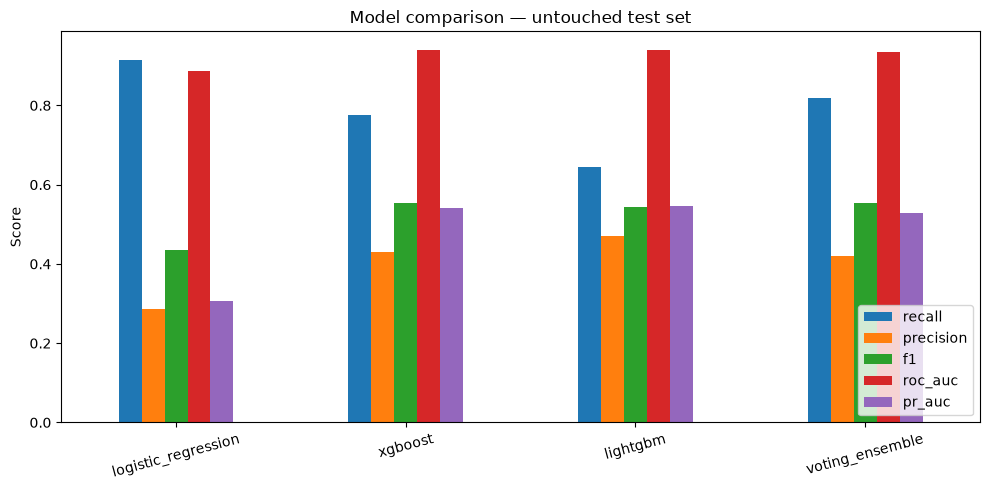

In [2]:
comparison = pd.DataFrame(metrics_all).T
print(comparison)

fig, ax = plt.subplots(figsize=(10, 5))
comparison.plot(kind="bar", ax=ax)
ax.set_ylabel("Score")
ax.set_title("Model comparison — untouched test set")
ax.legend(loc="lower right")
plt.xticks(rotation=15)
plt.tight_layout()
save_fig(fig, "10_model_comparison_bars")
plt.show()

## ROC and Precision-Recall curves — all models overlaid

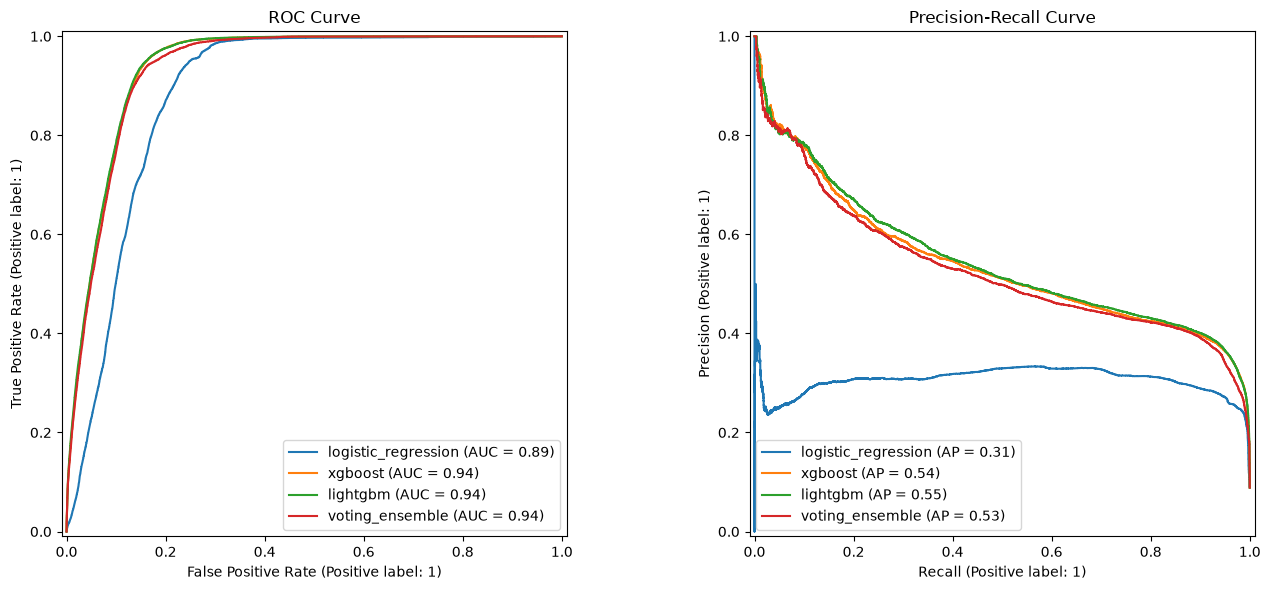

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for name, model in fitted.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=axes[0], name=name)
    PrecisionRecallDisplay.from_estimator(model, X_test, y_test, ax=axes[1], name=name)

axes[0].set_title("ROC Curve")
axes[1].set_title("Precision-Recall Curve")
plt.tight_layout()
save_fig(fig, "11_roc_pr_curves")
plt.show()

## Confusion matrices — leading candidates (XGBoost, LightGBM)

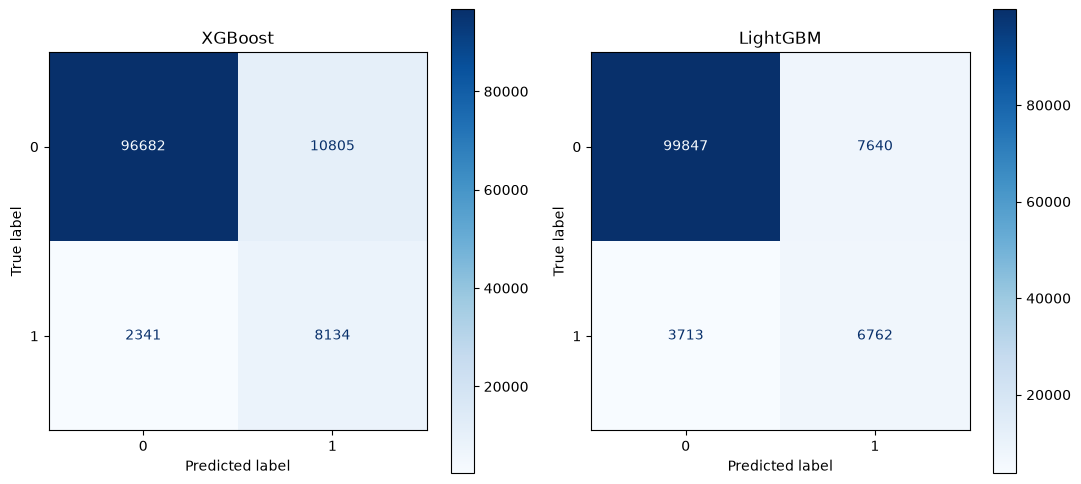

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
ConfusionMatrixDisplay.from_estimator(
    fitted["xgboost"], X_test, y_test, ax=axes[0], cmap="Blues", values_format="d"
)
axes[0].set_title("XGBoost")
ConfusionMatrixDisplay.from_estimator(
    fitted["lightgbm"], X_test, y_test, ax=axes[1], cmap="Blues", values_format="d"
)
axes[1].set_title("LightGBM")
plt.tight_layout()
save_fig(fig, "12_confusion_matrices")
plt.show()

**Observations**

- **XGBoost and LightGBM clearly outperform Logistic Regression on F1, ROC-AUC and PR-AUC**, even though Logistic Regression has the highest recall (0.92) of the four models — its precision (0.29) is much lower, so it also produces far more false positives. This is expected since tree-based models capture more complex relationships in the data, including native splits on the categorical features (gender, marital_status, customer_language) that Logistic Regression can only see one-hot-encoded.

- **The voting ensemble does not clearly beat the best individual model.** It achieves higher recall (0.82) than XGBoost or LightGBM alone, but its F1 (0.555) is essentially tied with XGBoost's (0.553), likely because combining it with the weaker Logistic Regression dilutes the stronger individual models.

- **ROC curves:** XGBoost, LightGBM and the voting ensemble almost overlap and are all far above Logistic Regression, showing excellent discrimination between churners and non-churners.

- **PR curves:** XGBoost and LightGBM consistently stay above Logistic Regression across most recall values, confirming better performance on this imbalanced dataset. The voting ensemble follows a similar trend but has a slightly lower PR-AUC than either individual model (0.529 vs. 0.541–0.547) — not an improvement.

- **Confusion matrices:** Logistic Regression predicts many more customers as churners, resulting in the highest number of false positives. XGBoost and LightGBM greatly reduce false positives while still detecting most churners.

**Leading candidates:** **XGBoost** and **LightGBM**. They're essentially tied on F1
(0.553 vs 0.544) and PR-AUC (0.541 vs 0.547), with LightGBM very slightly ahead on
ROC-AUC (0.9400 vs 0.9389). Both remain strong candidates for threshold optimization;
LightGBM is used as the primary model for explainability going forward, consistent
with earlier steps.